In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, log_loss, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import sys
import re
import seaborn as sns

import os
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [2]:
print(os.getcwd())
# os.chdir('Untitled Folder')
# print(os.getcwd())

/home/jovyan/Untitled Folder


In [ ]:
from Questions_7_8.cleaning_Q7_Q8 import process_data

from Questions_1_2.cleaning_Q1_Q2 import parse_q2_response

from Questions_4_5.cleanQ4Q5 import create_movie_features, extract_prices
from Questions_4_5.cleanQ4Q5 import create_movie_features_bow

from cleanDataQ3Q6 import map_drink


In [4]:
data = pd.read_csv("cleaned_data_combined_modified.csv")

def load_data(file_path):
    return pd.read_csv(file_path)

In [5]:
def process_q1_data(df):
    q1_col = [col for col in df.columns if 'Q1' in col][0]

    def extract_numeric(value):
        if pd.isna(value):
            return np.nan
        if isinstance(value, (int, float)):
            return float(value)
        matches = re.findall(r'\d+', str(value))
        if matches:
            return float(matches[0])
        return np.nan

    q1_values = df[q1_col].apply(extract_numeric)

    q1_features = np.array(q1_values).reshape(-1, 1)

    median_value = np.nanmedian(q1_features)
    q1_features = np.nan_to_num(q1_features, nan=median_value)

    return q1_features, "complexity_rating"

In [6]:
def process_q2_data_fix(df):
    q2_col = [col for col in df.columns if 'Q2' in col][0]

    word_bank_by_label = {
        'Pizza': {'cheese', 'tomato', 'dough', 'pepperoni', 'sauce', 'basil', 'water', 'oil', 'meat', 'olives'},
        'Shawarma': {'meat', 'pita', 'garlic', 'tahini', 'salad', 'onion', 'chicken', 'sauce', 'fries', 'rice'},
        'Sushi': {'rice', 'fish', 'seaweed', 'soy', 'wasabi', 'ginger', 'salmon', 'avocado'}
    }

    def clean_q2_row(row):
        bank = word_bank_by_label.get(row["Label"], None)
        return parse_q2_response(row[q2_col], word_bank=bank)

    q2_cleaned = df.apply(clean_q2_row, axis=1)

    q2_features = np.array(q2_cleaned).reshape(-1, 1)

    median_value = np.nanmedian(q2_features)
    q2_features = np.nan_to_num(q2_features, nan=median_value)

    return q2_features, "ingredient_count"

In [7]:
def process_q3q6_data(df):
    """
    Process Q3 (meal occasion) and Q6 (drink pairing) into bag of words features.

    Args:
        df: DataFrame containing the survey data

    Returns:
        q3_features: numpy array of shape (n_samples, n_q3_words)
        q6_features: numpy array of shape (n_samples, n_q6_words)
        q3_word_to_idx: dictionary mapping Q3 words to column indices
        q6_word_to_idx: dictionary mapping Q6 drinks to column indices
    """
    q3_col = [col for col in df.columns if 'Q3' in col][0]
    df.loc[:, q3_col] = df[q3_col].fillna('').str.lower().str.strip()

    q6_col = [col for col in df.columns if 'Q6' in col][0]
    df.loc[:, q6_col] = df[q6_col].fillna('').str.lower().str.strip()

    df.loc[:, q6_col] = df[q6_col].apply(map_drink)

    all_q3_words = set()
    for response in df[q3_col].dropna():
        words = response.split(',')
        all_q3_words.update(word.strip() for word in words if word.strip())

    q3_word_to_idx = {word: idx for idx, word in enumerate(sorted(all_q3_words))}

    all_q6_words = set()
    for response in df[q6_col].dropna():
        words = response.split(',')
        all_q6_words.update(word.strip() for word in words if word.strip())

    q6_word_to_idx = {word: idx for idx, word in enumerate(sorted(all_q6_words))}

    n_samples = len(df)
    n_q3_words = len(q3_word_to_idx)
    n_q6_words = len(q6_word_to_idx)

    q3_features = np.zeros((n_samples, n_q3_words))
    q6_features = np.zeros((n_samples, n_q6_words))

    for i, response in enumerate(df[q3_col].fillna('')):
        if response:
            words = response.split(',')
            for word in words:
                word = word.strip()
                if word and word in q3_word_to_idx:
                    q3_features[i, q3_word_to_idx[word]] = 1

    for i, response in enumerate(df[q6_col].fillna('')):
        if response:
            words = response.split(',')
            for word in words:
                word = word.strip()
                if word and word in q6_word_to_idx:
                    q6_features[i, q6_word_to_idx[word]] = 1

    return q3_features, q6_features, q3_word_to_idx, q6_word_to_idx

In [8]:
def process_q4_data_fix(df):
    q4_col = [col for col in df.columns if 'Q4' in col][0]

    def extract_price(value):
        if pd.isna(value):
            return np.nan
        if isinstance(value, (int, float)):
            return float(value)
        matches = re.findall(r'\d+(?:\.\d+)?', str(value))
        if matches:
            return float(max(matches, key=float))
        return np.nan

    q4_values = df[q4_col].apply(extract_price)

    q4_features = np.array(q4_values).reshape(-1, 1)

    median_value = np.nanmedian(q4_features)
    q4_features = np.nan_to_num(q4_features, nan=median_value)
    return q4_features, "price_expectation"
     

In [ ]:
train_data_path = "cleaned_data_combined.csv"
df = pd.read_csv(train_data_path)
print(df.head())

In [ ]:
df_train, df_valid = train_test_split(df, test_size=0.3, random_state=42)

print(f"Train size: {len(df_train)}  Test size: {len(df_valid)}")

train_features_list = []
valid_features_list = []
feature_names = []

q1_train_features, q1_name = process_q1_data(df_train)
q1_valid_features, _ = process_q1_data(df_valid)
train_features_list.append(q1_train_features)
valid_features_list.append(q1_valid_features)
feature_names.append(q1_name)

q2_train_features, q2_name = process_q2_data_fix(df_train)
q2_valid_features, _ = process_q2_data_fix(df_valid)
train_features_list.append(q2_train_features)
valid_features_list.append(q2_valid_features)
feature_names.append(q2_name)

q3_train_features, q6_train_features, q3_word_to_idx, q6_word_to_idx = process_q3q6_data(df_train)
q3_valid_features = np.zeros((len(df_valid), len(q3_word_to_idx)))
q6_valid_features = np.zeros((len(df_valid), len(q6_word_to_idx)))

q3_col = [col for col in df_valid.columns if 'Q3' in col][0]
q6_col = [col for col in df_valid.columns if 'Q6' in col][0]

for i, response in enumerate(df_valid[q3_col].fillna('')):
    if response:
        for word in response.split(','):
            word = word.strip().lower()
            if word in q3_word_to_idx:
                q3_valid_features[i, q3_word_to_idx[word]] = 1

for i, response in enumerate(df_valid[q6_col].fillna('')):
    if response:
        for word in response.split(','):
            word = word.strip().lower()
            if word in q6_word_to_idx:
                q6_valid_features[i, q6_word_to_idx[word]] = 1

train_features_list.append(q3_train_features)
train_features_list.append(q6_train_features)
valid_features_list.append(q3_valid_features)
valid_features_list.append(q6_valid_features)
feature_names.extend([f'q3_{word}' for word in sorted(q3_word_to_idx.keys())])
feature_names.extend([f'q6_{word}' for word in sorted(q6_word_to_idx.keys())])

q4_train_features, q4_name = process_q4_data_fix(df_train)
q4_valid_features, _ = process_q4_data_fix(df_valid)
train_features_list.append(q4_train_features)
valid_features_list.append(q4_valid_features)
feature_names.append(q4_name)

q5_train_features, q5_word_to_idx = create_movie_features(df_train)
q5_valid_features = np.zeros((len(df_valid), len(q5_word_to_idx)))
q5_col = [col for col in df_valid.columns if 'Q5' in col][0]
for i, response in enumerate(df_valid[q5_col].fillna('')):
    if response:
        for movie in response.split(','):
            movie = movie.strip().lower()
            if movie in q5_word_to_idx:
                q5_valid_features[i, q5_word_to_idx[movie]] = 1
                
train_features_list.append(q5_train_features)
valid_features_list.append(q5_valid_features)
feature_names.extend([f'q5_{movie}' for movie in sorted(q5_word_to_idx.keys())])

q7_train_features, q8_train_features, q7_word_to_idx, q8_category_to_idx = process_data(df_train)
q7_valid_features, q8_valid_features, _, _ = process_data(df_valid)
train_features_list.append(q7_train_features)
train_features_list.append(q8_train_features)
valid_features_list.append(q7_valid_features)
valid_features_list.append(q8_valid_features)
feature_names.extend([f'q7_{word}' for word in sorted(q7_word_to_idx.keys())])
feature_names.extend([f'q8_{cat}' for cat in sorted(q8_category_to_idx.keys())])

X_train = np.hstack(train_features_list)
X_valid = np.hstack(valid_features_list)

y_train = df_train['Label'].values
y_valid = df_valid['Label'].values

In [11]:
# Random Forest Model

In [40]:
print(X_train.shape)
print(X_valid.shape)

(1150, 600)
(494, 600)


In [ ]:
# analysis without pca data

param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [10, 20, 30, None], 
    'min_samples_split': [2, 5, 10, 20],  # needs more samples to split
    'min_samples_leaf': [2, 5, 10, 15]  # needs more samples per leaf
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

y_pred_rf = best_rf.predict(X_valid)
y_pred_train = best_rf.predict(X_train)

print("\nBest Random Forest Parameters:", grid_search.best_params_)
print("\nRandom Forest Validation Accuracy:", accuracy_score(y_valid, y_pred_rf))
print("\nRandom Forest Training Accuracy:", accuracy_score(y_train, y_pred_train))

print("\nClassification Report:\n", classification_report(y_valid, y_pred_rf))

In [12]:
rf = RandomForestClassifier(random_state=42, max_depth=10,min_samples_leaf=2,min_samples_split=2, n_estimators=200)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_valid)
y_pred_train = rf.predict(X_train)
print("\nRandom Forest Validation Accuracy:", accuracy_score(y_valid, y_pred_rf))
print("\nRandom Forest Training Accuracy:", accuracy_score(y_train, y_pred_train))



Random Forest Validation Accuracy: 0.8765182186234818

Random Forest Training Accuracy: 0.8895652173913043


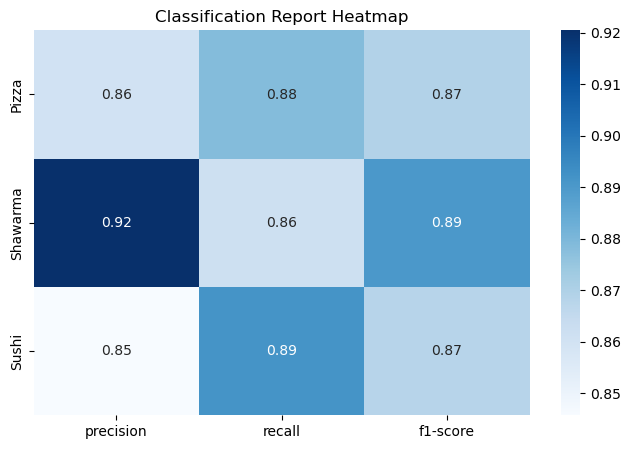

In [13]:


# Generate classification report as a dictionary
report_dict = classification_report(y_valid, y_pred_rf, output_dict=True)

# Convert to DataFrame
df_report = pd.DataFrame(report_dict).transpose()

# Drop the last 3 rows: 'accuracy', 'macro avg', 'weighted avg'
df_report = df_report[:-3]  # Removes the last three rows

# Drop the 'support' column if present
df_report = df_report.drop(columns=['support'], errors='ignore')

# Plot the heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df_report, annot=True, cmap="Blues", fmt=".2f")
plt.title("Classification Report Heatmap")
plt.show()


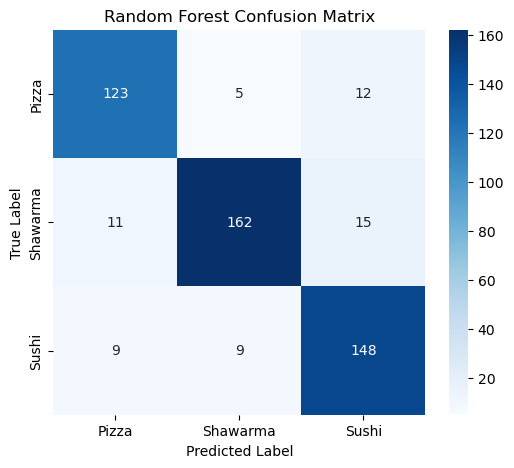

In [14]:
cm = confusion_matrix(y_valid, y_pred_rf)
labels = ["Pizza", "Shawarma", "Sushi"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

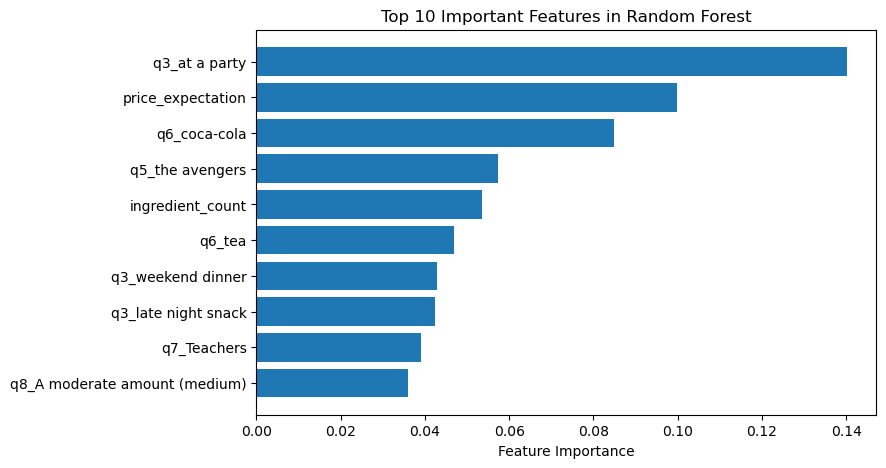

[CV] END max_depth=None, min_samples_leaf=15, min_samples_split=10, n_estimators=150; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=15, min_samples_split=10, n_estimators=150; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=15, min_samples_split=10, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=15, min_samples_split=20, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=15, min_samples_split=20, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=15, min_samples_split=20, n_estimators=150; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=15, min_samples_split=20, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_sp

[CV] END max_depth=None, min_samples_leaf=15, min_samples_split=20, n_estimators=150; total time=   0.1s
[CV] END max_depth=None, min_samples_leaf=15, min_samples_split=20, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, min_samples_leaf=15, min_samples_split=20, n_estimators=200; total time=   0.2s


In [15]:
# feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]  #top 10 features


plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Top 10 Important Features in Random Forest")
plt.show()